# Text in Matplotlib

## Basic Text Commands

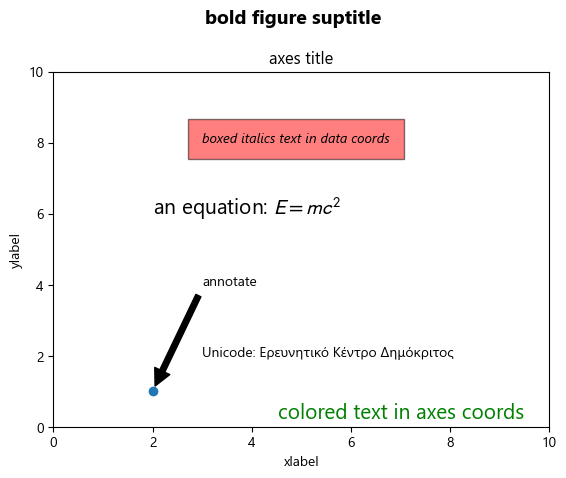

In [88]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

fig = plt.figure()
ax = fig.add_subplot()
fig.subplots_adjust(top=0.85)

# Set titles for the figure and the subplot respectively
fig.suptitle("bold figure suptitle", fontsize=14, fontweight="bold")
ax.set_title("axes title")

ax.set_xlabel("xlabel")
ax.set_ylabel("ylabel")

# Set both x- and y-axis limits to [0, 10] instead of default [0, 1]
ax.axis((0, 10, 0, 10))

ax.text(
    3,
    8,
    "boxed italics text in data coords",
    style="italic",
    bbox={
        "facecolor": "red",
        "alpha": 0.5,
        "pad": 10,
    },
)

ax.text(2, 6, r"an equation: $E=mc^2$", fontsize=15)
ax.text(3, 2, "Unicode: Ερευνητικό Κέντρο Δημόκριτος")

ax.text(
    0.95,
    0.01,
    "colored text in axes coords",
    verticalalignment="bottom",
    horizontalalignment="right",
    transform=ax.transAxes,
    color="green",
    fontsize=15,
)

ax.plot([2], [1], "o")
ax.annotate(
    "annotate",
    xy=(2, 1),
    xytext=(3, 4),
    arrowprops=dict(facecolor="black", shrink=0.05),
)

plt.show()

## Labels for x- and y-axis

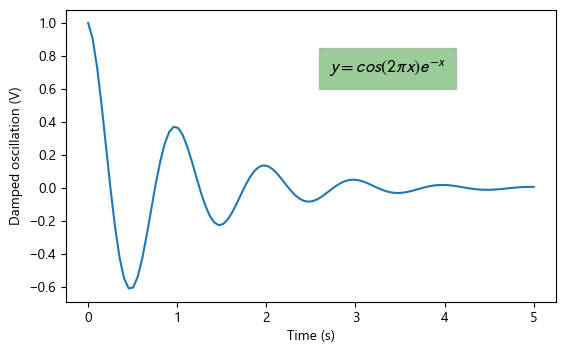

In [89]:
x1 = np.linspace(0.0, 5.0, 100)
y1 = np.cos(2 * np.pi * x1) * np.exp(-x1)

fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(bottom=0.15, left=0.2)
ax.plot(x1, y1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Damped oscillation (V)")
ax.text(
    2.7,
    0.7,
    r"$y=cos(2 \pi x)e^{-x}$",
    fontsize=13,
    bbox=dict(
        facecolor="green",
        edgecolor="gray",
        alpha=0.4,
        pad=7,
    ),
)

plt.show()

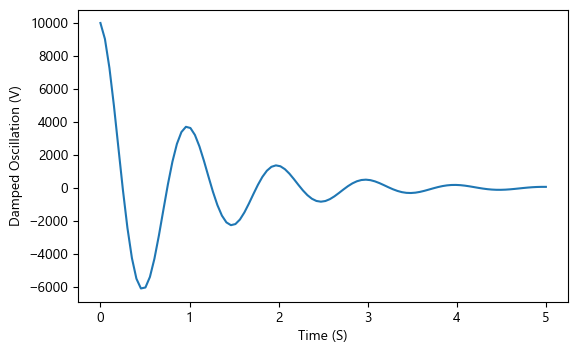

In [90]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(bottom=0.15, left=0.2)
ax.plot(x1, y1 * 10000)
ax.set_xlabel("Time (S)")
ax.set_ylabel("Damped Oscillation (V)")

plt.show()

To move the labels away from the Axes, use `labelpad`

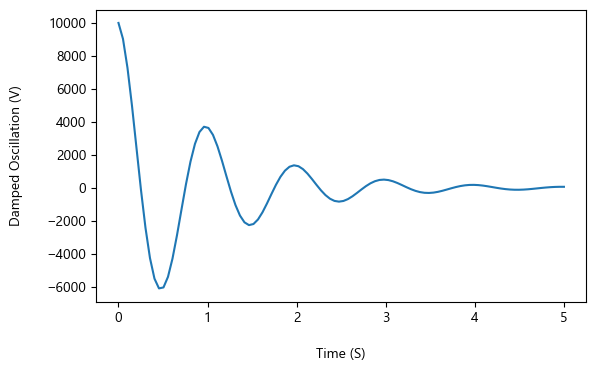

In [91]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(bottom=0.15, left=0.2)
ax.plot(x1, y1 * 10000)
ax.set_xlabel("Time (S)", labelpad=17)
ax.set_ylabel("Damped Oscillation (V)", labelpad=17)

plt.show()

To move the labels **along** the Axes, use `position`

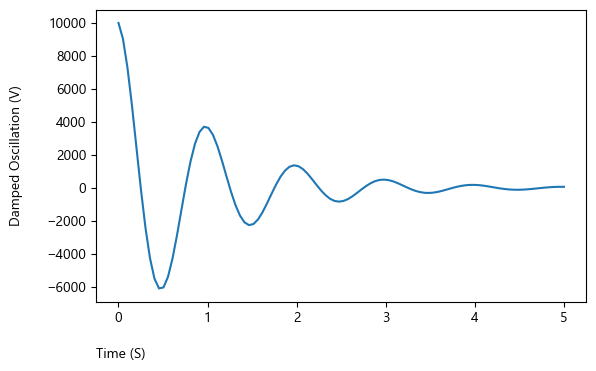

In [92]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(bottom=0.15, left=0.2)
ax.plot(x1, y1 * 10000)
ax.set_xlabel("Time (S)", labelpad=17, position=(0, 1e6), horizontalalignment="left")
ax.set_ylabel("Damped Oscillation (V)", labelpad=17)

plt.show()

Change label properties with `matplotlib.font_manager.FontProperties`

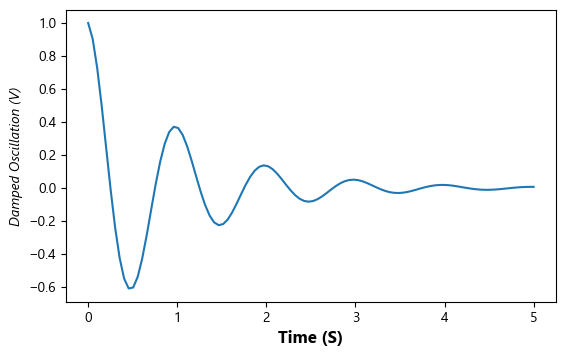

In [93]:
from matplotlib.font_manager import FontProperties

font = FontProperties(family="Segoe UI", style="italic", stretch=1000)

fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(bottom=0.15, left=0.2)
ax.plot(x1, y1)
ax.set_xlabel("Time (S)", fontsize="large", fontweight="bold")
ax.set_ylabel("Damped Oscillation (V)", fontproperties=font)

plt.show()

Use native **TeX** rendering

Text(0, 0.5, '$\\int\\ Y^2\\ dt\\ \\ (V^2 s)$')

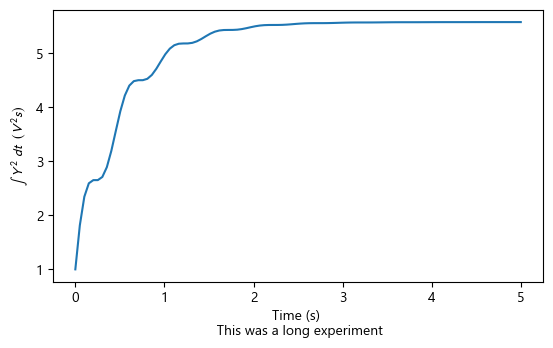

In [94]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(bottom=0.2, left=0.2)
ax.plot(x1, np.cumsum(y1**2))
ax.set_xlabel("Time (s) \n This was a long experiment")
ax.set_ylabel(r"$\int\ Y^2\ dt\ \ (V^2 s)$")

## Titles

Change a title's **position** and **justification** with `loc`

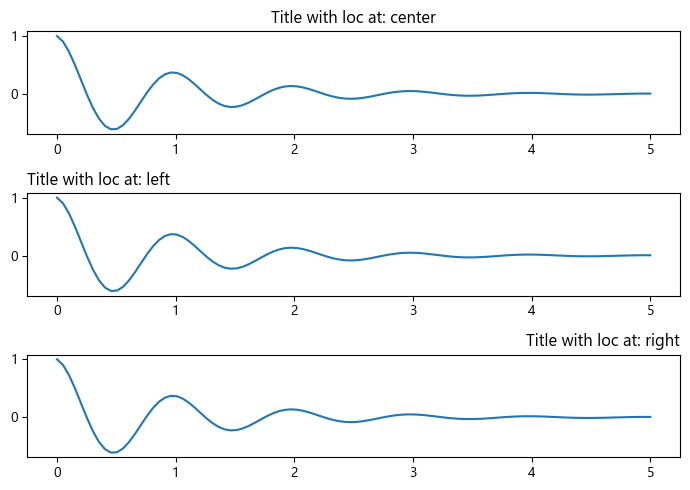

In [95]:
fig, axs = plt.subplots(3, 1, figsize=(7, 5), tight_layout=True)

locs = ["center", "left", "right"]

for ax, loc in zip(axs, locs):
    ax.plot(x1, y1)
    ax.set_title(f"Title with loc at: {loc}", loc=loc)

Control vertical spacing of titles

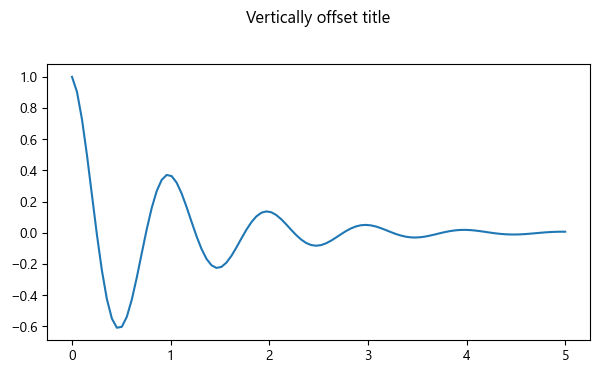

In [96]:
fig, ax = plt.subplots(figsize=(7, 4))
fig.subplots_adjust(top=0.8)
ax.plot(x1, y1)
ax.set_title("Vertically offset title", pad=30)

plt.show()

## Ticks and Ticklabels
> <span style="color:#F15A9B;font-style:italic;font-weight:500;">set_major_locator, set_minor_locator</span><br/>
    Use the data being plotted to determine the position of major and minor ticks.<br/><br/>
    <span style="color:#F15A9B;font-style:italic;font-weight:500;">set_major_formatter, set_minor_formatter</span><br/>
    Methods for formatting the tick labels.

### Simple Ticks
In the second Axes object we **explicitly** set the locations of the x-axis ticks. This however resets the axis limits outside the automatic view limits.

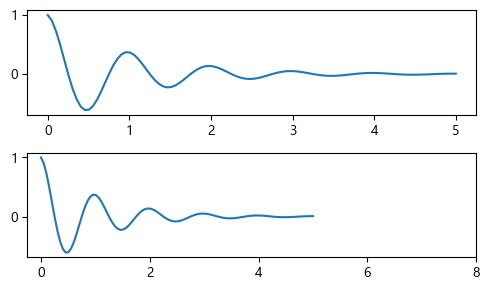

In [97]:
fig, axs = plt.subplots(2, 1, figsize=(5, 3), tight_layout=True)

axs[0].plot(x1, y1)
axs[1].plot(x1, y1)
axs[1].xaxis.set_ticks(np.arange(0, 8.1, 2))

plt.show()

We can also change the **format** of the ticks:

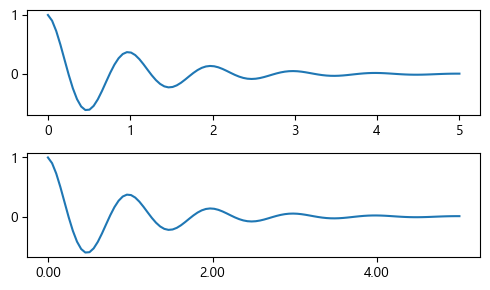

In [98]:
fig, axs = plt.subplots(2, 1, figsize=(5, 3), tight_layout=True)

axs[0].plot(x1, y1)
axs[1].plot(x1, y1)
ticks = np.arange(0.0, 8.1, 2)

# list comprehension to get all tick labels...
tickla = [f"{tick:1.2f}" for tick in ticks]
axs[1].xaxis.set_ticks(ticks)
axs[1].xaxis.set_ticklabels(tickla)
axs[1].set_xlim(axs[0].get_xlim())

plt.show()

### Tick Locators and Formatters
Instead of creating a list with all the tick labels, use `set_major_formatter`

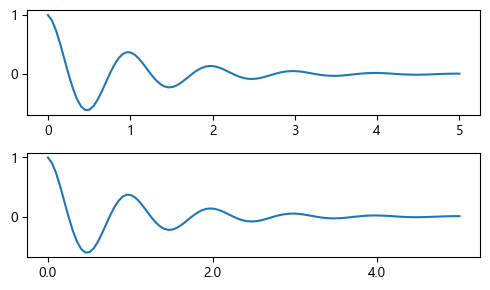

In [99]:
fig, axs = plt.subplots(2, 1, figsize=(5, 3), tight_layout=True)

axs[0].plot(x1, y1)
axs[1].plot(x1, y1)
ticks = np.arange(0.0, 8.1, 2)

axs[1].xaxis.set_ticks(ticks)
axs[1].xaxis.set_major_formatter("{x:1.1f}")
axs[1].set_xlim(axs[0].get_xlim())

plt.show()

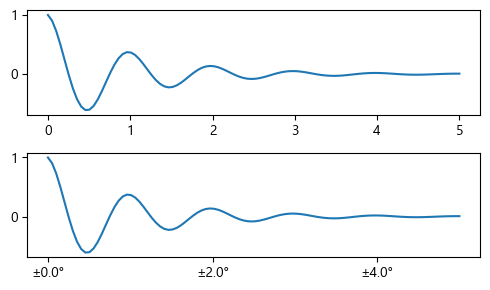

In [100]:
import matplotlib.ticker

fig, axs = plt.subplots(2, 1, figsize=(5, 3), tight_layout=True)

axs[0].plot(x1, y1)
axs[1].plot(x1, y1)

locator = matplotlib.ticker.FixedLocator(list(ticks))
axs[1].xaxis.set_major_locator(locator)
axs[1].xaxis.set_major_formatter("±{x}°")

plt.show()

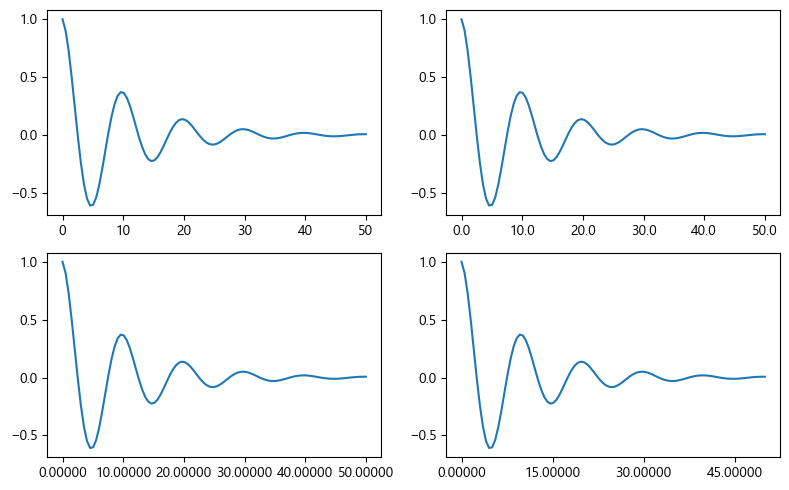

In [101]:
fig, axs = plt.subplots(2, 2, figsize=(8, 5), tight_layout=True)

for n, ax in enumerate(axs.flat):
    ax.plot(x1 * 10.0, y1)

formatter = matplotlib.ticker.FormatStrFormatter("%1.1f")
locator = matplotlib.ticker.MaxNLocator(nbins="auto", steps=[1, 4, 10])
axs[0, 1].xaxis.set_major_locator(locator)
axs[0, 1].xaxis.set_major_formatter(formatter)

formatter = matplotlib.ticker.FormatStrFormatter("%1.5f")
locator = matplotlib.ticker.AutoLocator()
axs[1, 0].xaxis.set_major_locator(locator)
axs[1, 0].xaxis.set_major_formatter(formatter)

formatter = matplotlib.ticker.FormatStrFormatter("%1.5f")
locator = matplotlib.ticker.MaxNLocator(nbins=4)
axs[1, 1].xaxis.set_major_locator(locator)
axs[1, 1].xaxis.set_major_formatter(formatter)

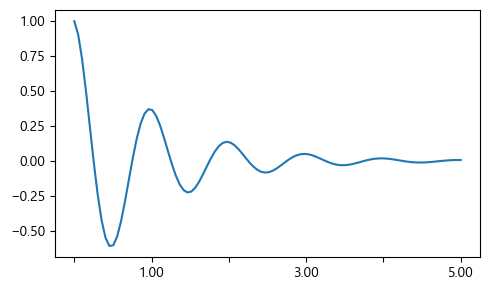

In [102]:
def formatoddticks(x, pos):
    """Format odd tick positions."""
    if x % 2:
        return f"{x:1.2f}"
    else:
        return ""


fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True)
ax.plot(x1, y1)

locator = matplotlib.ticker.MaxNLocator(nbins=6)
ax.xaxis.set_major_formatter(formatoddticks)
ax.xaxis.set_major_locator(locator)

### Dateticks

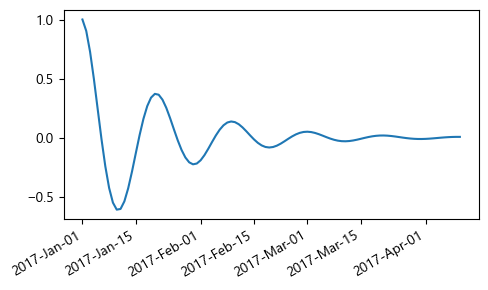

In [103]:
import datetime
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True)
base = datetime.datetime(2017, 1, 1, 0, 0, 1)
time = [base + datetime.timedelta(days=x) for x in range(len(x1))]

ax.plot(time, y1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%b-%d"))
fig.autofmt_xdate()
plt.show()

# Text Properties and Layout

Text(0.5, 0.5, 'middle')

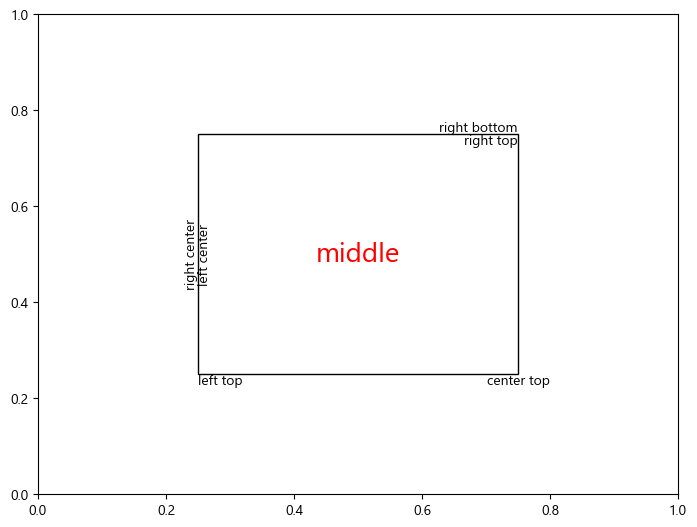

In [104]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig = plt.figure()

# add an Axes to the figure, with dimensions defined in the argument
# (left, bottom, width, height) in fractions of figure width and height.
ax = fig.add_axes((0, 0, 1, 1))

# build a rectangle in axes coords
left, bottom, width, height = 0.25, 0.25, 0.5, 0.5
right = left + width
top = bottom + height

# The rectangle's anhor point is (0.25, 0.25) and its width and height
# are both 0.5 in axes coordinates.
p = patches.Rectangle(
    (left, bottom),
    width,
    height,
    fill=False,
    transform=ax.transAxes,
    clip_on=False,
)
ax.add_patch(p)

# NOTE: By default the position of the text is in data coordinates,
#       so we specify that the position we give is in axes coordinates
#       by using transform=ax.transAxes.
ax.text(
    left,
    bottom,
    "left top",
    horizontalalignment="left",
    verticalalignment="top",
    transform=ax.transAxes,
)
ax.text(
    right,
    top,
    "right bottom",
    horizontalalignment="right",
    verticalalignment="bottom",
    transform=ax.transAxes,
)
ax.text(
    right,
    top,
    "right top",
    horizontalalignment="right",
    verticalalignment="top",
    transform=ax.transAxes,
)
ax.text(
    right,
    bottom,
    "center top",
    horizontalalignment="center",
    verticalalignment="top",
    transform=ax.transAxes,
)
ax.text(
    left,
    0.5 * (bottom + top),
    "right center",
    horizontalalignment="right",
    verticalalignment="center",
    rotation="vertical",
    transform=ax.transAxes,
)
ax.text(
    left,
    0.5 * (bottom + top),
    "left center",
    horizontalalignment="left",
    verticalalignment="center",
    rotation="vertical",
    transform=ax.transAxes,
)
ax.text(
    0.5 * (left + right),
    0.5 * (bottom + top),
    "middle",
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=20,
    color="red",
    transform=ax.transAxes,
)

## Default Font

In [105]:
matplotlib.rcParams["font.family"] = ["Segoe UI", "Source Code Pro", "sans-serif"]

# Annotations

## Basic Annotation

The **xy** (data point to annotate & arrow tipe) and **xytext** (text location), are both in data coordinates.

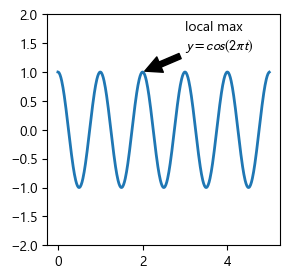

In [106]:
fig, ax = plt.subplots(figsize=(3, 3))

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2 * np.pi * t)
(line,) = ax.plot(t, s, lw=2)

ax.annotate(
    "local max\n$y=cos(2 \\pi t)$",
    xy=(2, 1),  # the data point to annotate
    xytext=(3, 1.4),  # the position of the text
    arrowprops=dict(facecolor="black", shrink=0.05),
)
ax.set_ylim(-2, 2)
plt.show()

### Annotating Data

Use **textcoords** to change the coordinate system of the text, to **"axes fraction"** where (0, 0) is the lower left of Axes and (1, 1) is the upper right.

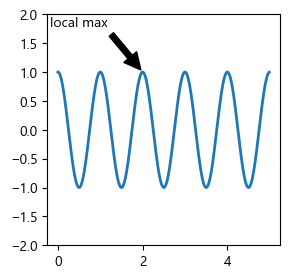

In [107]:
fig, ax = plt.subplots(figsize=(3, 3))

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2 * np.pi * t)
(line,) = ax.plot(t, s, lw=2)

ax.annotate(
    "local max",
    xy=(2, 1),  # the data point is
    xycoords="data",  # in data coordinate system
    xytext=(0.01, 0.99),  # the text location is
    textcoords="axes fraction",  # in fraction of the Axes
    va="top",
    ha="left",
    arrowprops=dict(facecolor="black", shrink=0.05),
)
ax.set_ylim(-2, 2)

plt.show()

### Annotating an Artist

If we pass an Artist (e.g. an arrow) as **xycoords**, then **xy** is read as fraction of the Artist's bbox.

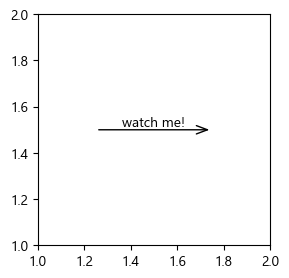

In [108]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(3, 3))
arr = mpatches.FancyArrowPatch(
    (1.25, 1.5),  # start of the arrow
    (1.75, 1.5),  # end of the arrow
    arrowstyle="->,head_width=0.15",
    mutation_scale=20,
)
ax.add_patch(arr)
ax.annotate(
    "watch me!",
    (0.5, 0.5),
    xycoords=arr,
    ha="center",
    va="bottom",
)
ax.set(xlim=(1, 2), ylim=(1, 2))
plt.show()

### Annotating with Arrows

Text(0.05, 0.05, 'a polar annotation')

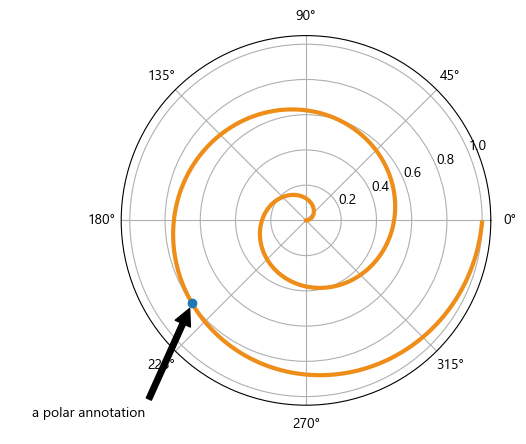

In [109]:
fig = plt.figure()
ax = fig.add_subplot(projection="polar")

r = np.arange(0, 1, 0.001)
theta = 2 * 2 * np.pi * r

(line,) = ax.plot(theta, r, color="#EE8D18", lw=3)

ind = 800
thisr, thistheta = r[ind], theta[ind]

ax.plot([thistheta], [thisr], "o")
ax.annotate(
    "a polar annotation",
    xy=(thistheta, thisr),
    xytext=(0.05, 0.05),
    textcoords="figure fraction",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="left",
    verticalalignment="bottom",
)

### Placing Text Annotations Relative to Data

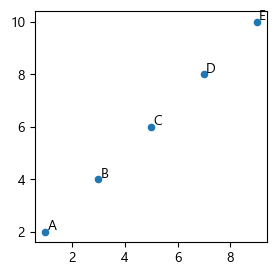

In [110]:
fig, ax = plt.subplots(figsize=(3, 3))

x = [1, 3, 5, 7, 9]
y = [2, 4, 6, 8, 10]

annotations = ["A", "B", "C", "D", "E"]
ax.scatter(x, y, s=20)

for xi, yi, text in zip(x, y, annotations):
    # Returns 3-tuples; the first is (1, 2, "A"), second is (3, 4, "B")...
    ax.annotate(
        text,
        xy=(xi, yi),
        xycoords="data",
        xytext=(1.5, 1.5),
        textcoords="offset points",
    )

plt.show()

## Advanced Annotation
### Annotating with Boxed Text

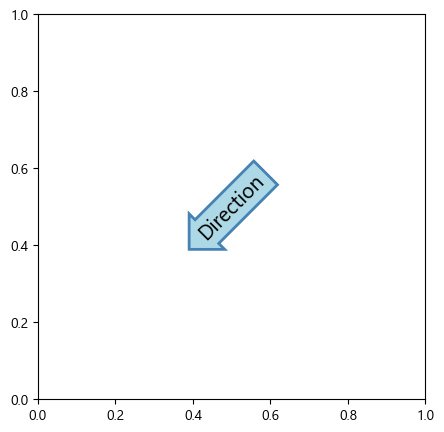

In [111]:
fig, ax = plt.subplots(figsize=(5, 5))

# The boxstyle can take values such as:
# circle,pad=0.3
# ellipse,pad=0.3
# rarrow,pad=0.3 ...
t = ax.text(
    0.5,
    0.5,
    "Direction",
    ha="center",
    va="center",
    rotation=45,
    size=15,
    bbox=dict(
        boxstyle="larrow,pad=0.3",
        fc="lightblue",
        ec="steelblue",
        lw=2,
    ),
)

### Defining Custom Box Styles

Text(0.5, 0.5, 'Test')

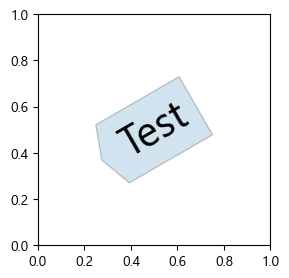

In [112]:
from matplotlib.path import Path


def custom_box_style(x0, y0, width, height, mutation_size):
    """
    Given the location and size of the box, return the path of the box around it.
    Rotation is automatically taken care of.

    Parameters
    ----------
        x0, y0 (float): Box location
        width, height (float): Box size
        mutation_size (float): Mutation reference scale, typically the text font size.
    """

    # padding
    mypad = 0.3
    pad = mutation_size * mypad

    # width & height with padding added
    width = width + 2 * pad
    height = height + 2 * pad

    # boundary of the padded box
    x0, y0 = x0 - pad, y0 - pad
    x1, y1 = x0 + width, y0 + height

    # return the new path
    return Path([(x0, y0), (x1, y0), (x1, y1), (x0, y1), (x0 - pad, (y0 + y1) / 2), (x0, y0), (x0, y0)], closed=True)


fig, ax = plt.subplots(figsize=(3, 3))
ax.text(
    0.5,
    0.5,
    "Test",
    size=30,
    va="center",
    ha="center",
    rotation=30,
    bbox=dict(boxstyle=custom_box_style, alpha=0.2),
)

### Customizing Annotation Arrows

An arrow connecting the point to the text. Here we show only the arrow by using an empty string.

Text(0.8, 0.8, '')

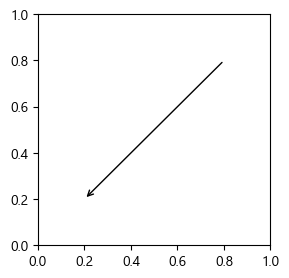

In [113]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.annotate(
    "",
    xy=(0.2, 0.2),
    xytext=(0.8, 0.8),
    textcoords="data",
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
)

Text(0.8, 0.8, 'Test')

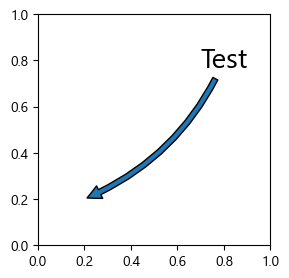

In [114]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.annotate(
    "Test",
    xy=(0.2, 0.2),
    xycoords="data",
    xytext=(0.8, 0.8),
    textcoords="data",
    size=20,
    va="center",
    ha="center",
    arrowprops=dict(
        arrowstyle="simple",
        connectionstyle="arc3,rad=-0.2",
    ),
)

Text(0.8, 0.8, 'Test')

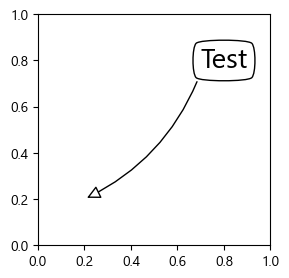

In [115]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.annotate(
    "Test",
    xy=(0.2, 0.2),
    xycoords="data",
    xytext=(0.8, 0.8),
    textcoords="data",
    size=20,
    va="center",
    ha="center",
    bbox=dict(
        boxstyle="round4",
        fc="w",
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        connectionstyle="arc3,rad=-0.2",
        relpos=(0, 0),
        fc="w",
    ),
)

Text(0.8, 0.8, 'Test')

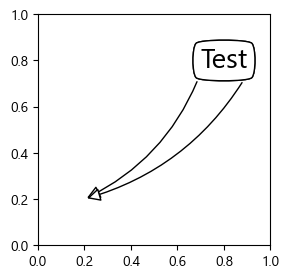

In [116]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.annotate(
    "Test",
    xy=(0.2, 0.2),
    xycoords="data",
    xytext=(0.8, 0.8),
    textcoords="data",
    size=20,
    va="center",
    ha="center",
    bbox=dict(
        boxstyle="round4",
        fc="w",
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        connectionstyle="arc3,rad=-0.2",
        relpos=(0, 0),
        fc="w",
    ),
)

ax.annotate(
    "Test",
    xy=(0.2, 0.2),
    xycoords="data",
    xytext=(0.8, 0.8),
    textcoords="data",
    size=20,
    va="center",
    ha="center",
    bbox=dict(
        boxstyle="round4",
        fc="w",
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        connectionstyle="arc3,rad=-0.2",
        relpos=(1, 0),
        fc="w",
    ),
)

### Placing Artist at Anchored Axes Location

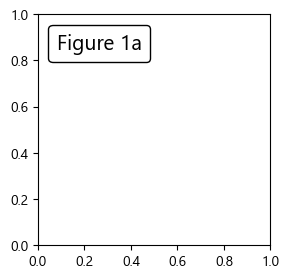

In [117]:
from matplotlib.offsetbox import AnchoredText

fig, ax = plt.subplots(figsize=(3, 3))
at = AnchoredText(
    "Figure 1a",
    prop=dict(size=15),
    frameon=True,
    loc="upper left",
)
at.patch.set_boxstyle("round,pad=0,rounding_size=0.2")
ax.add_artist(at)

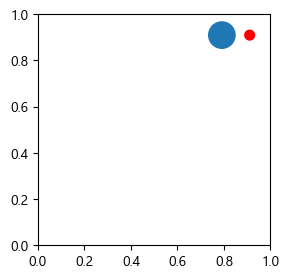

In [118]:
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredDrawingArea

fig, ax = plt.subplots(figsize=(3, 3))
ada = AnchoredDrawingArea(40, 20, 0, 0, loc="upper right", pad=0, frameon=False)
p1 = Circle((10, 10), 10)
ada.drawing_area.add_artist(p1)
p2 = Circle((30, 10), 4, fc="r")
ada.drawing_area.add_artist(p2)
ax.add_artist(ada)

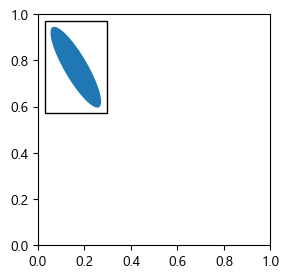

In [119]:
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredAuxTransformBox

fig, ax = plt.subplots(figsize=(3, 3))
box = AnchoredAuxTransformBox(ax.transData, loc="upper left")
el = Ellipse((0, 0), width=0.1, height=0.4, angle=30)
box.drawing_area.add_artist(el)
ax.add_artist(box)

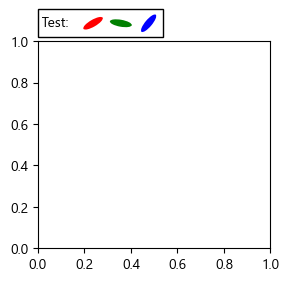

In [120]:
from matplotlib.offsetbox import AnchoredOffsetbox, DrawingArea, HPacker, TextArea

fig, ax = plt.subplots(figsize=(3, 3))

box1 = TextArea(" Test: ", textprops=dict(color="k"))
box2 = DrawingArea(60, 20, 0, 0)

el1 = Ellipse((10, 10), width=16, height=5, angle=30, fc="r")
el2 = Ellipse((30, 10), width=16, height=5, angle=170, fc="g")
el3 = Ellipse((50, 10), width=16, height=5, angle=230, fc="b")
box2.add_artist(el1)
box2.add_artist(el2)
box2.add_artist(el3)

box = HPacker(children=[box1, box2], align="center", pad=0, sep=5)
anchored_box = AnchoredOffsetbox(
    loc="lower left",
    child=box,
    pad=0,
    frameon=True,
    bbox_to_anchor=(0, 1.02),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

ax.add_artist(anchored_box)
fig.subplots_adjust(top=0.8)

## Coordinate Systems for Annotations
### Transform Instance

### Artist Instance

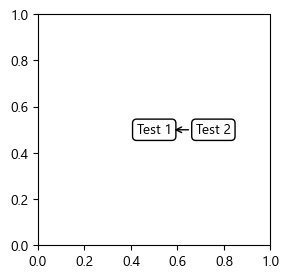

In [121]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3))

an1 = ax.annotate(
    "Test 1",
    xy=(0.5, 0.5),
    xycoords="data",
    va="center",
    ha="center",
    bbox=dict(boxstyle="round", fc="w"),
)
an2 = ax.annotate(
    "Test 2",
    xy=(1, 0.5),
    xycoords=an1,
    xytext=(30, 0),
    textcoords="offset points",
    va="center",
    ha="center",
    bbox=dict(boxstyle="round", fc="w"),
    arrowprops=dict(arrowstyle="->"),
)

# Fonts in Matplotlib

# Writing Mathematical Expressions

To process a string as **Mathtext**, place it inside a pair of dollar signs `$`, and write it using `raw strings` (in which case the backslashes do not need to be escaped).

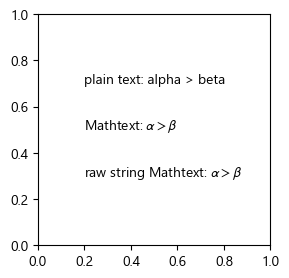

In [122]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
ax.text(0.2, 0.7, "plain text: alpha > beta")
ax.text(0.2, 0.5, "Mathtext: $\\alpha > \\beta$")
ax.text(0.2, 0.3, r"raw string Mathtext: $\alpha > \beta$")

plt.show()

## Special Characters

Text(0.1, 0.1, 'even: $ \\delta $ = $ \\$4 $')

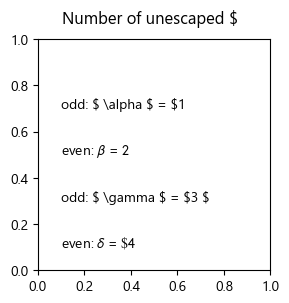

In [123]:
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Number of unescaped $")
ax.text(0.1, 0.7, r"odd: $ \alpha $ = $1")
ax.text(0.1, 0.5, r"even: $ \beta $ = $ 2 $")
ax.text(0.1, 0.3, r"odd: $ \gamma $ = \$3 $")
ax.text(0.1, 0.1, r"even: $ \delta $ = $ \$4 $")

## Subscripts and Superscripts

Text(0.1, 0.3, '$\\sum_{i=0}^\\infty x_i$')

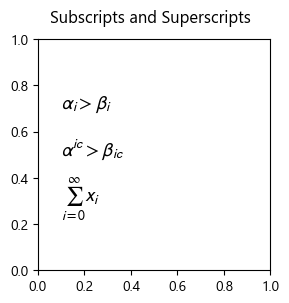

In [124]:
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Subscripts and Superscripts")

# use "_" for a subscript and "^" for superscript
ax.text(0.1, 0.7, r"$\alpha_i > \beta_i$", fontsize=14)
# place multi-letter subscripts inside curly braces
ax.text(0.1, 0.5, r"$\alpha^{ic} > \beta_{ic}$", fontsize=14)
ax.text(0.1, 0.3, r"$\sum_{i=0}^\infty x_i$", fontsize=14)

## Fractions, Binomials and Stacked Numbers

Text(0.1, 0.3, '$\\genfrac{}{}{0}{}{3}{4}$')

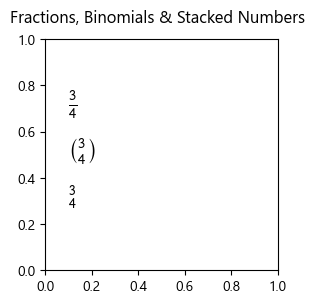

In [125]:
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Fractions, Binomials & Stacked Numbers")
ax.text(0.1, 0.7, r"$\frac{3}{4}$", fontsize=15)
ax.text(0.1, 0.5, r"$\binom{3}{4}$", fontsize=15)
ax.text(0.1, 0.3, r"$\genfrac{}{}{0}{}{3}{4}$", fontsize=14)

## Radicals

Text(0.1, 0.5, '$\\sqrt[3]{x}$')

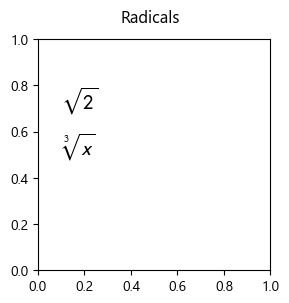

In [126]:
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Radicals")

ax.text(0.1, 0.7, r"$\sqrt{2}$", fontsize=15)
# Use square brackets for the radical base
ax.text(0.1, 0.5, r"$\sqrt[3]{x}$", fontsize=15)

## Fonts

Text(0.1, 0.8, '$s(t) = \\mathcal{A} \\ sin \\ (2 \\omega t)$')

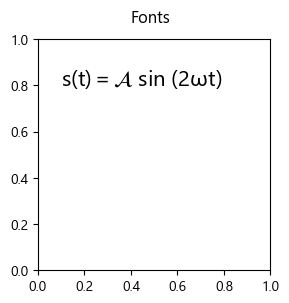

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Fonts")

# Default is italics (it). 
plt.rcParams["mathtext.default"] = "regular"
ax.text(0.1, 0.8, r"$s(t) = \mathcal{A} \ sin \ (2 \omega t)$", fontsize=16)

# plt.rcParams["mathtext.fontset"] = "stixsans"

Text(0.1, 0.6, '$s(t) = \\mathcal{A} \\ sin \\ (2 \\omega t)$')

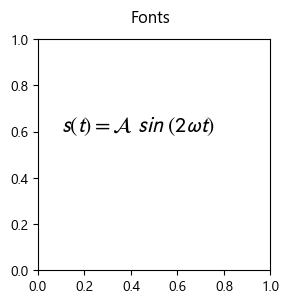

In [131]:
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Fonts")

# May also change it to regular.
plt.rcParams["mathtext.default"] = "it"
ax.text(0.1, 0.6, r"$s(t) = \mathcal{A} \ sin \ (2 \omega t)$", fontsize=16)

Text(0.1, 0.6, '$s(t) = \\mathcal{A} \\ \\mathrm{sin} \\ (2 \\omega t)$')

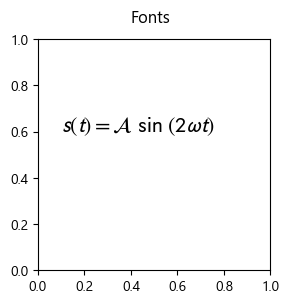

In [134]:
# To write a part of Mathtext e.g the sin, in Roman, use a font command
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Fonts")

ax.text(0.1, 0.6, r"$s(t) = \mathcal{A} \ \mathrm{sin} \ (2 \omega t)$", fontsize=16)

Text(0.1, 0.6, '$s(t) = \\mathcal{A} \\sin \\ (2 \\omega t)$')

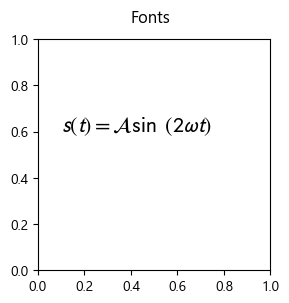

In [ ]:
# Or simply
fig, ax = plt.subplots(figsize=(3, 3), linewidth=1)
fig.suptitle("Fonts")

ax.text(0.1, 0.6, r"$s(t) = \mathcal{A} \sin \ (2 \omega t)$", fontsize=16)

Available choices for all fonts are:
- `\mathrm{item}` print item in Roman
- `\mathit{item}` print item in italics
- `\mathtt{item}` print item in TypeWriter font
- `\mathcal{item}` print item in Calligraphy

## Accents

Text(0.1, 0.2, '$A \\cup B - Union$')

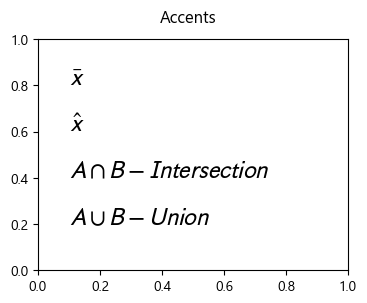

In [149]:
fig, ax = plt.subplots(figsize=(4, 3), linewidth=1)
fig.suptitle("Accents")

ax.text(0.1, 0.8, r"$\bar{x}$", fontsize=18)
ax.text(0.1, 0.6, r"$\hat x$", fontsize=18)
ax.text(0.1, 0.4, r"$A \cap B - Intersection$", fontsize=18)
ax.text(0.1, 0.2, r"$A \cup B - Union$", fontsize=18)